# 第 11 章 · 悬崖行走探索策略代码实验

本页从起点动作开始拆解悬崖行走：先看哪一步会掉下悬崖，再比较不同探索强度下的路径学习。

[章节网页](../ch11.html)

## 运行内容

- 查看起点候选动作
- 比较不同探索率
- 绘制完成路线与策略

## 0. 悬崖行走任务

先看起点四个动作的一步结果，再看训练曲线和最终策略。这样读者能把探索风险、即时奖励和路线选择连起来。

In [1]:
# 载入本页会用到的数据集、模型和绘图工具。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from IPython.display import display
from scipy.signal import correlate2d
from sklearn.datasets import load_breast_cancer, load_digits, load_iris, load_sample_image, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.svm import SVC

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 载入强化学习经典环境。
if importlib.util.find_spec("gymnasium") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "gymnasium>=0.29"])

import gymnasium as gym

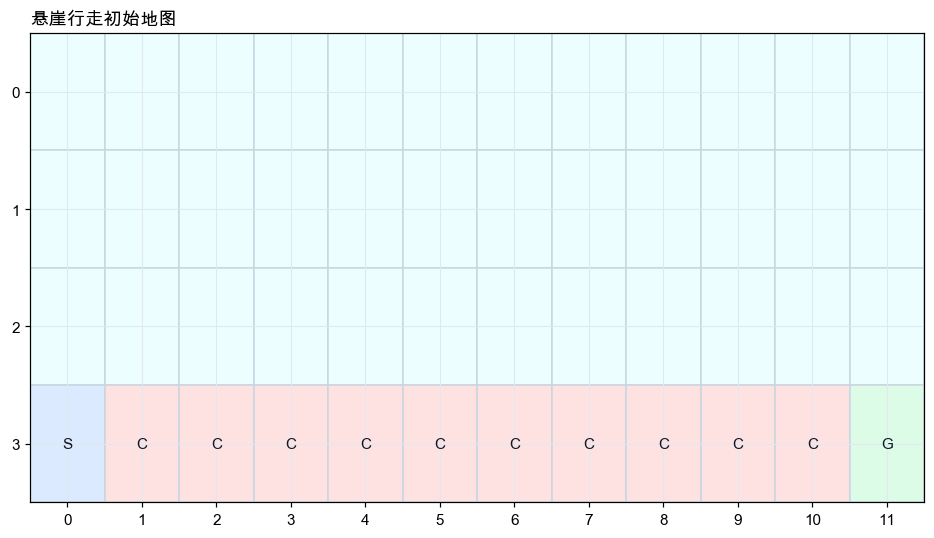

,当前位置,尝试动作,一步后位置,即时奖励,含义
0,"(3,0) 起点",向上,"(2,0)",-1,安全移动或撞墙停留
1,"(3,0) 起点",向右,"(3,0)",-100,踩到悬崖，回到起点
2,"(3,0) 起点",向下,"(3,0)",-1,安全移动或撞墙停留
3,"(3,0) 起点",向左,"(3,0)",-1,安全移动或撞墙停留


,策略,读法,风险
0,选择当前 Q 最大动作,走已经学到的最好方向,可能过早固定路线
1,以探索率随机尝试,故意试试看其他方向,可能踩到悬崖，但也可能发现更短路线


In [3]:
# 悬崖行走：先看地图，再看起点四个动作的一步结果。
cliff_action_labels = ["向上", "向右", "向下", "向左"]
cliff_action_arrows = {0: "↑", 1: "→", 2: "↓", 3: "←"}

cliff_layout = np.full((4, 12), "safe", dtype=object)
cliff_layout[3, 0] = "start"
cliff_layout[3, 11] = "goal"
cliff_layout[3, 1:11] = "cliff"

fig, ax = plt.subplots(figsize=(8.6, 5.0))
color_map = {"safe": "#ecfeff", "start": "#dbeafe", "goal": "#dcfce7", "cliff": "#fee2e2"}
label_map = {"safe": "", "start": "S", "goal": "G", "cliff": "C"}
for r in range(4):
    for c in range(12):
        cell = cliff_layout[r, c]
        ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, color=color_map[cell], ec="#cbd5e1"))
        ax.text(c, r, label_map[cell], ha="center", va="center", fontweight="bold", color="#0f172a")
ax.set_title("悬崖行走初始地图", loc="left", fontweight="bold")
ax.set_xlim(-0.5, 11.5)
ax.set_ylim(3.5, -0.5)
ax.set_xticks(range(12))
ax.set_yticks(range(4))
ax.grid(True, color="#e2e8f0", linewidth=0.7)
plt.tight_layout()
plt.show()

def inspect_cliff_start_actions():
    env = gym.make("CliffWalking-v0")
    rows = []
    for action, action_name in enumerate(cliff_action_labels):
        state, _ = env.reset(seed=0)
        next_state, reward, terminated, truncated, _ = env.step(action)
        row, col = divmod(state, 12)
        next_row, next_col = divmod(next_state, 12)
        rows.append({
            "当前位置": f"({row},{col}) 起点",
            "尝试动作": action_name,
            "一步后位置": f"({next_row},{next_col})",
            "即时奖励": reward,
            "含义": "踩到悬崖，回到起点" if reward <= -100 else "安全移动或撞墙停留",
        })
    env.close()
    return pd.DataFrame(rows)

display(inspect_cliff_start_actions())
display(pd.DataFrame({
    "策略": ["选择当前 Q 最大动作", "以探索率随机尝试"],
    "读法": ["走已经学到的最好方向", "故意试试看其他方向"],
    "风险": ["可能过早固定路线", "可能踩到悬崖，但也可能发现更短路线"],
}))

In [4]:
# 悬崖行走：在经典网格任务里比较不同探索率的 Q-learning。
def train_cliff_q_learning(epsilon, episodes=2000, alpha=0.50, gamma=1.0, seed=0):
    env = gym.make("CliffWalking-v0")
    env.action_space.seed(seed)
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    rows = []

    def best_action(state):
        values = Q[state]
        best_actions = np.flatnonzero(np.isclose(values, values.max()))
        # 并列时先离开悬崖边，再向右推进，避免未学习状态反复撞墙。
        for action in [0, 1, 2, 3]:
            if action in best_actions:
                return int(action)
        return int(best_actions[0])

    def choose_action(state):
        if rng.random() < epsilon:
            return env.action_space.sample()
        return best_action(state)

    for episode in range(1, episodes + 1):
        state, _ = env.reset(seed=seed + episode)
        total_reward = 0
        steps = 0
        terminated = truncated = False
        while not (terminated or truncated) and steps < 200:
            action = choose_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            target = reward + gamma * np.max(Q[next_state]) * (not (terminated or truncated))
            Q[state, action] += alpha * (target - Q[state, action])
            state = next_state
            total_reward += reward
            steps += 1
        if episode % 100 == 0:
            rows.append({"epsilon": epsilon, "episode": episode, "reward": total_reward, "steps": steps})
    env.close()
    return pd.DataFrame(rows), Q


cliff_runs = []
cliff_tables = {}
for eps in [0.05, 0.10, 0.30]:
    trace, Q = train_cliff_q_learning(eps, seed=21)
    cliff_runs.append(trace)
    cliff_tables[eps] = Q

cliff_trace = pd.concat(cliff_runs, ignore_index=True)
display(cliff_trace.tail(12).rename(columns={
    "epsilon": "探索率",
    "episode": "回合",
    "reward": "回合奖励",
    "steps": "步数",
}))

,探索率,回合,回合奖励,步数
48,0.3,900,-22,22
49,0.3,1000,-548,53
50,0.3,1100,-118,19
51,0.3,1200,-129,30
52,0.3,1300,-19,19
53,0.3,1400,-15,15
54,0.3,1500,-336,39
55,0.3,1600,-17,17
56,0.3,1700,-116,17
57,0.3,1800,-232,34


,步数,当前位置,动作,下一位置,奖励
0,1,"(3,0)",向上,"(2,0)",-1
1,2,"(2,0)",向右,"(2,1)",-1
2,3,"(2,1)",向右,"(2,2)",-1
3,4,"(2,2)",向右,"(2,3)",-1
4,5,"(2,3)",向右,"(2,4)",-1
5,6,"(2,4)",向右,"(2,5)",-1
6,7,"(2,5)",向右,"(2,6)",-1
7,8,"(2,6)",向右,"(2,7)",-1
8,9,"(2,7)",向右,"(2,8)",-1
9,10,"(2,8)",向右,"(2,9)",-1


,是否到达终点,路线步数,总奖励
0,True,13,-13


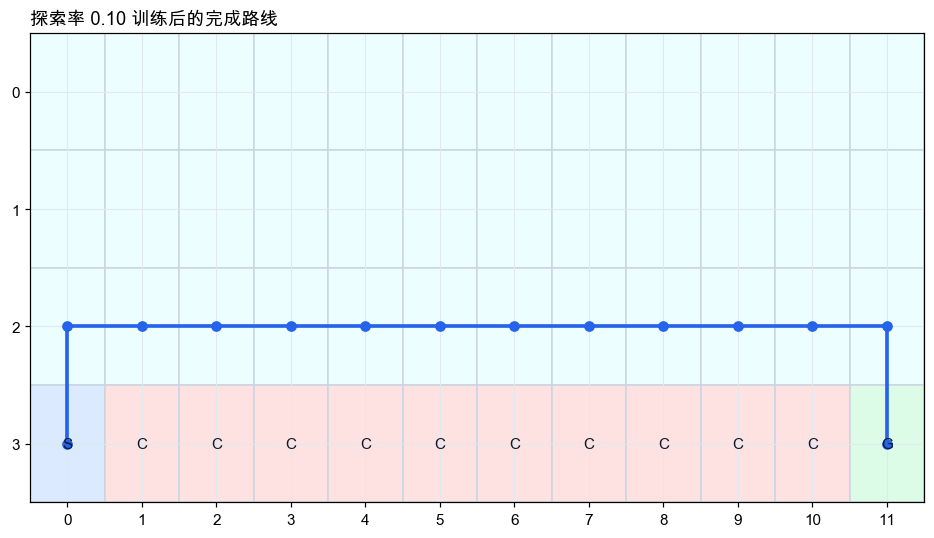

In [5]:
# 用训练后的 Q 表走一条贪心路线，查看智能体会如何从 S 走向 G。
def run_cliff_greedy_path(Q, max_steps=40):
    env = gym.make("CliffWalking-v0")
    state, _ = env.reset(seed=5)
    rows = []
    path_coords = [divmod(state, 12)]
    total_reward = 0
    finished = False
    for step in range(1, max_steps + 1):
        values = Q[state]
        best_actions = np.flatnonzero(np.isclose(values, values.max()))
        # 并列时优先向右推进，其次向上离开悬崖边。
        for candidate in [1, 0, 2, 3]:
            if candidate in best_actions:
                action = int(candidate)
                break
        else:
            action = int(best_actions[0])
        next_state, reward, terminated, truncated, _ = env.step(action)
        row, col = divmod(state, 12)
        next_row, next_col = divmod(next_state, 12)
        rows.append({
            "步数": step,
            "当前位置": f"({row},{col})",
            "动作": cliff_action_labels[action],
            "下一位置": f"({next_row},{next_col})",
            "奖励": reward,
        })
        path_coords.append((next_row, next_col))
        total_reward += reward
        state = next_state
        if terminated or truncated:
            finished = terminated
            break
    env.close()
    return pd.DataFrame(rows), path_coords, total_reward, finished


cliff_path_df, cliff_path_coords, cliff_path_reward, cliff_finished = run_cliff_greedy_path(cliff_tables[0.10])
display(cliff_path_df)
display(pd.DataFrame([{
    "是否到达终点": cliff_finished,
    "路线步数": len(cliff_path_df),
    "总奖励": cliff_path_reward,
}]))

fig, ax = plt.subplots(figsize=(8.6, 5.0))
for r in range(4):
    for c in range(12):
        cell = cliff_layout[r, c]
        ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, color=color_map[cell], ec="#cbd5e1"))
        ax.text(c, r, label_map[cell], ha="center", va="center", fontweight="bold", color="#0f172a")
ys = [r for r, _ in cliff_path_coords]
xs = [c for _, c in cliff_path_coords]
ax.plot(xs, ys, color="#2563eb", linewidth=2.4, marker="o")
ax.set_title("探索率 0.10 训练后的完成路线", loc="left", fontweight="bold")
ax.set_xlim(-0.5, 11.5)
ax.set_ylim(3.5, -0.5)
ax.set_xticks(range(12))
ax.set_yticks(range(4))
ax.grid(True, color="#e2e8f0", linewidth=0.7)
plt.tight_layout()
plt.show()

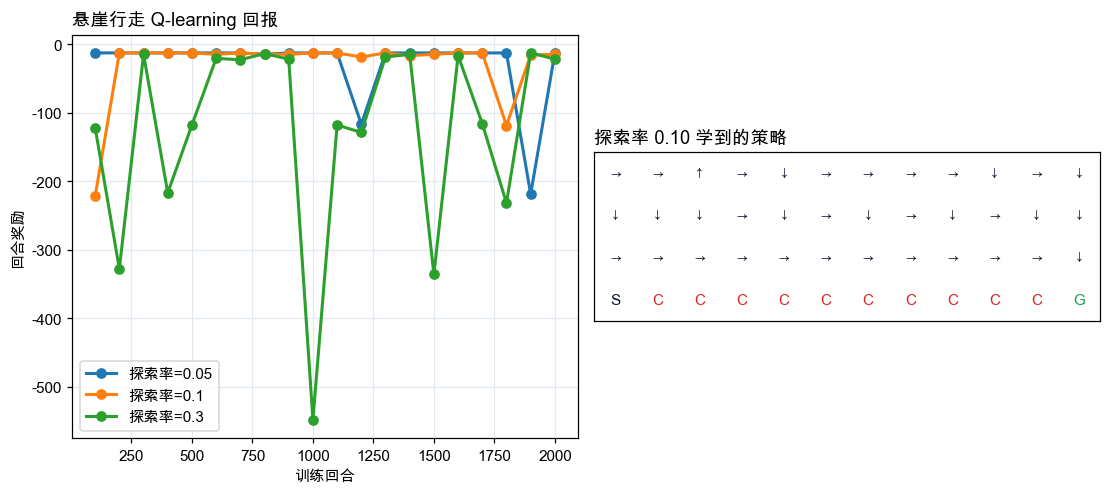

In [6]:
# 绘制探索率对悬崖行走学习表现的影响。
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.6))
for epsilon, part in cliff_trace.groupby("epsilon"):
    axes[0].plot(part["episode"], part["reward"], marker="o", linewidth=2.0, label=f"探索率={epsilon}")
axes[0].set_title("悬崖行走 Q-learning 回报", loc="left", fontweight="bold")
axes[0].set_xlabel("训练回合")
axes[0].set_ylabel("回合奖励")
axes[0].grid(True, color="#e2e8f0", linewidth=0.8)
axes[0].legend()

best_eps = 0.10
policy = np.argmax(cliff_tables[best_eps], axis=1).reshape(4, 12)
arrow = {0: "↑", 1: "→", 2: "↓", 3: "←"}
grid = np.zeros((4, 12))
axes[1].imshow(grid, cmap="Greys", vmin=0, vmax=1)
for r in range(4):
    for c in range(12):
        if r == 3 and 1 <= c <= 10:
            text = "C"
            color = "#dc2626"
        elif (r, c) == (3, 0):
            text = "S"
            color = "#0f172a"
        elif (r, c) == (3, 11):
            text = "G"
            color = "#16a34a"
        else:
            text = arrow[int(policy[r, c])]
            color = "#0f172a"
        axes[1].text(c, r, text, ha="center", va="center", color=color, fontweight="bold")
axes[1].set_title("探索率 0.10 学到的策略", loc="left", fontweight="bold")
axes[1].set_xticks([])
axes[1].set_yticks([])
plt.tight_layout()
plt.show()